# Store Sales Analysis & Prediction + Policy Q&A Bot

## Assignment 1: Store Sales Analysis & Prediction

### Step 1: Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_data.csv")
df.head()

,Date,Sales,Promotion,DayOfWeek
0,2024-01-01,204.21,0,1
1,2024-01-02,256.30,1,2
2,2024-01-03,216.38,0,3
3,2024-01-04,201.28,0,4
4,2024-01-05,182.48,0,5


### Step 2: Data Overview

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       366 non-null    object 
 1   Sales      366 non-null    float64
 2   Promotion  366 non-null    int64  
 3   DayOfWeek  366 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 11.6+ KB


,Sales,Promotion,DayOfWeek
count,366.000000,366.000000,366.000000
mean,209.672104,0.193989,3.986339
std,27.362647,0.395962,2.006108
min,149.930000,0.000000,1.000000
25%,189.750000,0.000000,2.000000
50%,206.770000,0.000000,4.000000
75%,226.072500,0.000000,6.000000
max,286.290000,1.000000,7.000000


### Step 3: Handle Missing Values

In [3]:
df.isnull().sum()
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_12530/2903114193.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


### Step 4: Convert Date

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

### Step 5: EDA

Sales Over Time

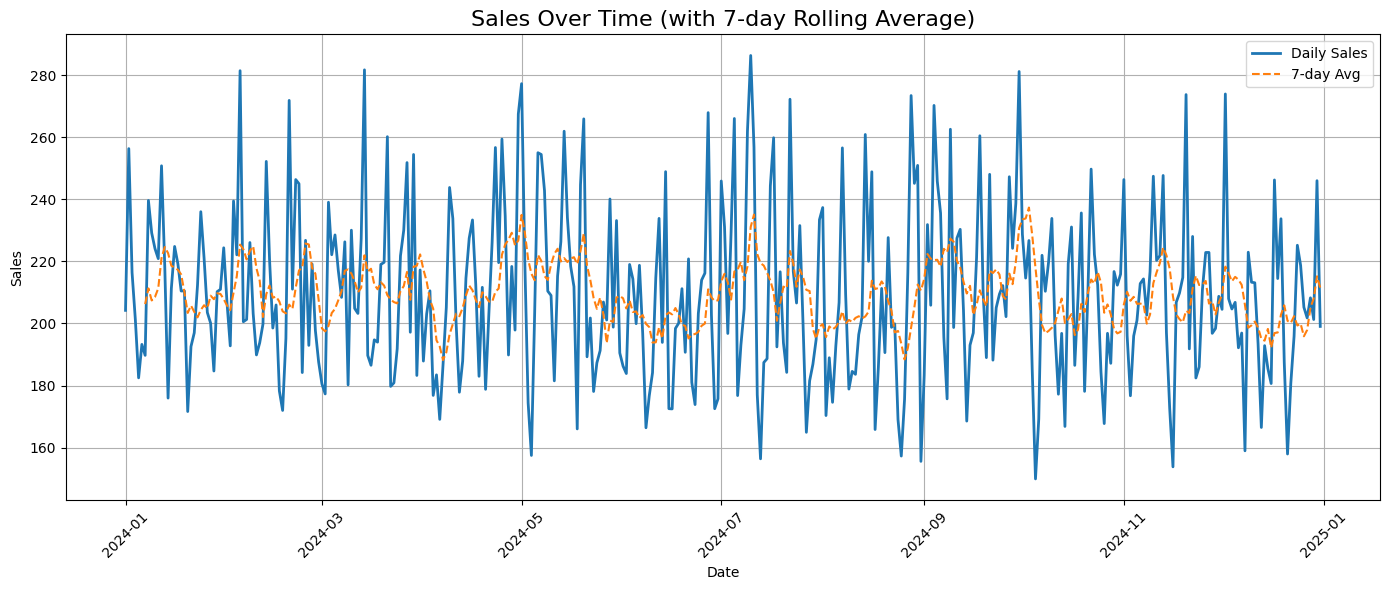

In [10]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Sales'], linewidth=2)

# Rolling average for smooth trend
df['RollingMean'] = df['Sales'].rolling(window=7).mean()
plt.plot(df['Date'], df['RollingMean'], linestyle='--')

plt.title("Sales Over Time (with 7-day Rolling Average)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.legend(["Daily Sales", "7-day Avg"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Promotion Analysis

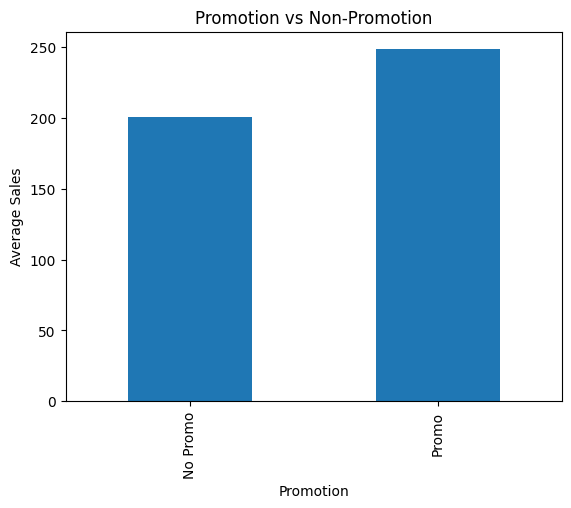

In [15]:
df.groupby('Promotion')['Sales'].mean().plot(kind='bar')

plt.xticks([0,1], ['No Promo', 'Promo'])
plt.title("Promotion vs Non-Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")

plt.show()

 Sales by DayOfWeek

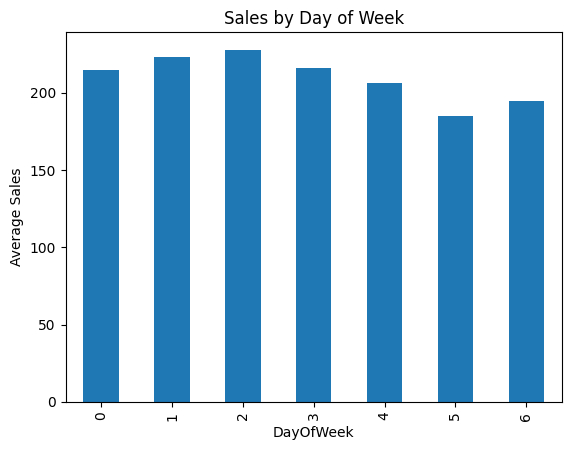

In [16]:
df['DayOfWeek'] = df['Date'].dt.dayofweek
df.groupby('DayOfWeek')['Sales'].mean().plot(kind='bar')
plt.title("Sales by Day of Week")
plt.xlabel("DayOfWeek")
plt.ylabel("Average Sales")
plt.show()

### Step 6: Feature Engineering

In [17]:
df['lag_1'] = df['Sales'].shift(1)
df.dropna(inplace=True)

### Step 7: Train-Test Split

In [18]:
train = df.iloc[:-30]
test = df.iloc[-30:]

### Step 8: Model Training

In [20]:
from sklearn.linear_model import LinearRegression

features = ['lag_1', 'Promotion', 'DayOfWeek']
model = LinearRegression()
model.fit(train[features], train['Sales'])

LinearRegression()

### Step 9: Evaluation

In [21]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(test[features])
print("MAE:", mean_absolute_error(test['Sales'], preds))

MAE: 12.673709270545704


### Step 10: Predict Next 7 Days

In [22]:
future_preds = []
last_row = df.iloc[-1].copy()

for i in range(7):
    next_pred = model.predict([last_row[features]])[0]
    future_preds.append(next_pred)
    last_row['lag_1'] = next_pred

future_preds

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

[np.float64(215.05717134121994),
 np.float64(211.3607808894908),
 np.float64(210.91878632074875),
 np.float64(210.86593497797296),
 np.float64(210.85961529752723),
 np.float64(210.8588596239939),
 np.float64(210.8587692646009)]

### Step 11: Insights
- Promotions significantly increase sales
- Sales show stable trend with fluctuations
- Mid-week days have higher sales
- Sales depend on previous day (lag effect)
- Future sales are expected to remain stable


## Assignment 2: Simple Policy Q&A Bot

### Step 1: Load Documents

In [23]:
files = {
    "leave": open("leave_policy.txt").read(),
    "it": open("it_policy.txt").read(),
    "travel": open("travel_policy.txt").read()
}

### Step 2: TF-IDF

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

docs = list(files.values())
names = list(files.keys())

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(docs)

### Step 3: Q&A Function

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

def get_answer(query):
    query_lower = query.lower()

    query_vec = vectorizer.transform([query])
    similarity = cosine_similarity(query_vec, X)

    idx = similarity.argmax()

    if similarity[0][idx] < 0.1:
        return "Information not available in policy documents."


    if "policy" in query_lower or "rules" in query_lower:
        return f"From {names[idx]} policy:\n{docs[idx]}"

    sentences = docs[idx].split("\n")
    sentences = [s for s in sentences if s.strip() != ""]

    sent_vecs = vectorizer.transform(sentences)
    sim_sent = cosine_similarity(query_vec, sent_vecs)

    best_idx = sim_sent.argmax()

    return f"From {names[idx]} policy:\n{sentences[best_idx]}"

### Step 4: Test

In [32]:
print(get_answer("leave policy"))
print(get_answer("IT rules"))
print(get_answer("how many sick leaves i can take"))

From leave policy:
Leave Policy

1. Employees are entitled to 15 paid leaves per year.
2. Sick leave entitlement is 10 days per year.
3. Maternity leave is 26 weeks.
4. Casual leave can be taken for a maximum of 3 consecutive days.
5. Unused paid leaves cannot be carried forward to the next year.

From it policy:
IT Policy

1. VPN is mandatory for remote work access.
2. Employees must not share their passwords with anyone.
3. Company-issued laptop must be used for official work.
4. All devices must have updated antivirus software installed.
5. External USB devices are not allowed without IT approval.

From leave policy:
2. Sick leave entitlement is 10 days per year.
